# Analysis

## Parse Data

In [36]:
import json
from pathlib import Path
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [37]:
languages = {
    'fra': 'French',
    'ber': 'Berber',
    'cmn': 'Chinese',
    'deu': 'German',
    'ita': 'Italian',
    'jpn': 'Japanese',
    'tur': 'Turkish',
    'ben': 'Bengali',
    'agg': 'Aggregated',
}

In [38]:
class Run:
    info: dict
    info_percents: dict = {}
    data: pd.DataFrame
    model: str
    thinking: bool
    prompt: str
    language: str
    samples: int

    def __init__(self, data: pd.DataFrame, source_file: Path | str, info: dict) -> None:
        self.data = data
        self.samples = data.shape[0]

        source_file = Path(source_file)
        config = source_file.stem.split("_")

        self.model = config[0]
        self.thinking = config[1] == "CoT"
        self.prompt = config[2]
        self.language = config[3]

        self.info = info
        self.set_info_percentages()

    def set_info_percentages(self):
        for key, value in self.info.items():
            self.info_percents[key] = value / self.samples

    def __repr__(self) -> str:
        content = (
            f"Run(model={self.model!r}, language={self.language!r}, prompt={self.prompt!r}, thinking={self.thinking!r}, samples={self.samples}, info={self.info!r}, info_percents={self.info_percents!r}, data={type(self.data)})"
        )
        self.data.info()
        return content

In [39]:
def read_to_json(json_arr: list[Path]) -> list[dict]:
    parsed = []
    for file in json_arr:
        parsed.append(json.load(open(file)))
    return parsed

def read_to_df(df_arr: list[Path]) -> list[pd.DataFrame]:
    parsed = []
    for file in df_arr:
        parsed.append(pd.read_csv(open(file)))
    return parsed

In [40]:
eval_path = Path(os.getcwd()) / "data/tatoeba/eval/Qwen"

info_paths = [f for f in eval_path.iterdir() if f.suffix == ".json"]
data_paths = [f for f in eval_path.iterdir() if f.suffix == ".csv"]

infos = read_to_json(info_paths)
dfs = read_to_df(data_paths)

runs = [Run(df, file, info) for df, info, file in zip(dfs, infos, data_paths)]

In [41]:
runs[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44383 entries, 0 to 44382
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   English               44383 non-null  object 
 1   Original_Translation  44383 non-null  object 
 2   AI_Translation        44383 non-null  object 
 3   AI_Confidence         44383 non-null  float64
 4   Score                 44383 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.7+ MB


Run(model='Qwen3-1.7B', language='deu', prompt='monolithic', thinking=True, samples=44383, info={'errors': 2547, 'malformatted_json': 0, 'nan_confidences': 78, 'other_nan': 0}, info_percents={'errors': 0.0011299070247933884, 'malformatted_json': 0.0011299070247933884, 'nan_confidences': 0.0, 'other_nan': 0.0}, data=<class 'pandas.core.frame.DataFrame'>)

## Construct graphs

In [42]:
def plot_cov_ellipse(x, y, n_std=2.0, ax=None, **kwargs):
    """
    Plot the covariance ellipse of (x, y).

    n_std: number of standard deviations (e.g. 1, 2, 3)
    """
    if ax is None:
        ax = plt.gca()

    data = np.column_stack((x, y))
    # 2x2 covariance matrix
    cov = np.cov(data, rowvar=False)
    # Mean
    mean = data.mean(axis=0)

    # Eigenvalues (variances) and eigenvectors (principal directions)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Angle of the largest eigenvector
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # Width and height of ellipse = 2 * n_std * sqrt(eigenvalues)
    width, height = 2 * n_std * np.sqrt(vals)

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=theta,
        fill=False,
        **kwargs
    )
    ax.add_patch(ell)
    return ell

In [43]:
def linear_regression(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    x = x.reshape(-1, 1)
    regression = LinearRegression().fit(x, y)
    slope = float(regression.coef_[0])
    intercept = regression.intercept_
    r2 = regression.score(x, y)
    return slope, intercept, r2

In [59]:
def plot(run: Run, print_fig: bool = False, save: bool = True, legend: bool = False, save_dir: str | None = None, restrict_axis: bool = False, title: str | None = None, hide_title: bool = False) -> None:
    mean_score = run.data['Score'].mean()
    median_score = run.data['Score'].median()
    mean_conf = run.data['AI_Confidence'].mean()
    median_conf = run.data['AI_Confidence'].median()

    slope, intercept, r2 = linear_regression(run.data['AI_Confidence'].to_numpy(), run.data['Score'].to_numpy())

    # if run.model == "Qwen3 both sizes":
    #     run.data = run.data.sample(100_000)

    fig, ax = plt.subplots(figsize=(6, 5))

    # Scatter or density plot
    if True: # run.samples > 200_000:
        # Use a hexbin density plot for large datasets to avoid millions of overlapping points
        hb = ax.hexbin(
            run.data['AI_Confidence'],
            run.data['Score'],
            gridsize=75,
            bins="log",
            mincnt=1,
        )
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label("Number of translations")
    else:
        # For smaller datasets, keep a regular scatter but rasterize the markers
        ax.scatter(
            run.data['AI_Confidence'],
            run.data['Score'],
            s=15,
            alpha=0.6,
            label="Translations",
            rasterized=True,
        )

    # Identity line
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.6, label="Ideal calibration")

    # Linear regression E[Y | X=x]
    x_pts = np.arange(0, 1.01, 0.01)
    regr_y = intercept + slope * x_pts
    ax.plot(x_pts, regr_y, 'k--', label="Regression")
    textstr = "\n".join((
        rf"$y = {slope:.3f}x + {intercept:.3f}$",
        rf"$R^2 = {r2:.3f}$",
    ))
    ax.text(
        0.95, 0.05, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    # Mean & median points
    ax.scatter(
        mean_conf, mean_score,
        color="green", s=80, marker="o",
        label=f"Mean ({mean_conf:.2f}, {mean_score:.2f})"
    )
    ax.scatter(
        median_conf, median_score,
        color="purple", s=80, marker="X",
        label=f"Median ({median_conf:.2f}, {median_score:.2f})"
    )

    # Covariance ellipse (2σ)
    ell = plot_cov_ellipse(
        run.data['AI_Confidence'],
        run.data['Score'],
        n_std=2.0,
        ax=ax,
        edgecolor="black",
        linestyle="--",
        linewidth=1.5,
        label="2σ covariance ellipse"
    )

    if not hide_title:
        ax.set_title(title if title else
        (
            f"Calibration of {run.model} "
            f"{'thinking' if run.thinking else 'basic'}\n"
            f"""{f"on {languages[run.language]} " if run.language != 'agg' else ""}"""
            f"with {run.prompt} prompt"
            f"""{f", aggregated on languages" if run.language == 'agg' else ""}"""
        ))
    ax.set_xlabel("AI Confidence")
    ax.set_ylabel("UniTE MT Score")

    if restrict_axis:
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

    if legend:
        if run.samples > 2_000_000:
            ax.legend(loc="center left", bbox_to_anchor=(1.3, 0.5))
        else:
            ax.legend()

    if save:
        fig_path = (Path(os.getcwd()) / "figures")
        if save_dir:
            fig_path = fig_path / save_dir
        pdf_path = fig_path / "pdf"

        fig_path.mkdir(parents=True, exist_ok=True)
        pdf_path.mkdir(parents=True, exist_ok=True)
        filename = f"{run.model.replace('.', '_')}_{'Thinking' if run.thinking else 'Basic'}_{run.prompt}_{run.language}"
        plt.savefig((fig_path / filename).with_suffix(".png"), bbox_inches="tight")
        plt.savefig((pdf_path / filename).with_suffix(".pdf"), bbox_inches="tight")

    if print_fig:
        plt.show()

    plt.close()

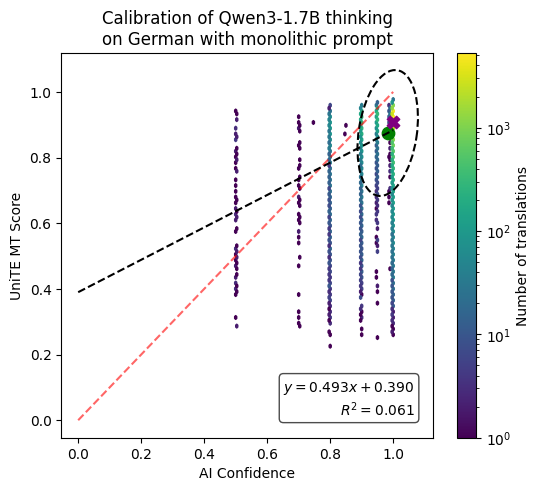

In [60]:
plot(runs[0], print_fig=True, save=False)

Save graphs for every run

In [63]:
for run in runs:
    plot(run, save_dir="individual", hide_title=True)

## Aggregate charts for relevant hyperparameters

In [47]:
# Exclude Berber from aggregation, as it's not reliable
no_berber = [run for run in runs if languages[run.language] != "Berber"]

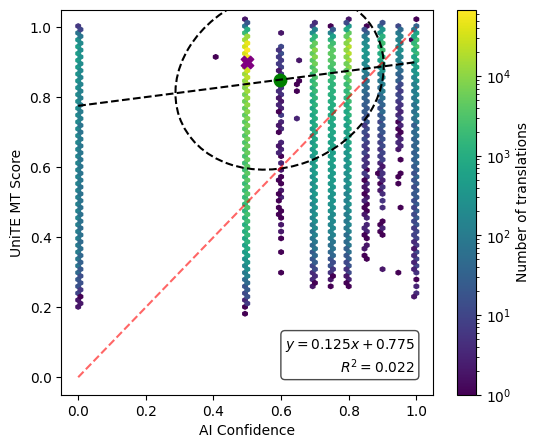

Qwen3-1.7B - iterative - False
count    1.011819e+06
mean     8.498615e-01
std      1.284083e-01
min      1.814042e-01
25%      8.138831e-01
50%      8.997631e-01
75%      9.340043e-01
max      1.022825e+00
Name: Score, dtype: float64



Qwen3-1.7B - iterative - True
count    248555.000000
mean          0.869381
std           0.118263
min           0.227788
25%           0.850693
50%           0.912615
75%           0.940585
max           1.016659
Name: Score, dtype: float64



Qwen3-1.7B - monolithic - False
count    1.012967e+06
mean     8.535805e-01
std      1.231970e-01
min      2.045415e-01
25%      8.189027e-01
50%      9.006328e-01
75%      9.342910e-01
max      1.022825e+00
Name: Score, dtype: float64



Qwen3-1.7B - monolithic - True
count    252054.000000
mean          0.865674
std           0.118420
min           0.199193
25%           0.844380
50%           0.908985
75%           0.938076
max           1.023040
Name: Score, dtype: float64



Qwen3-14B - iterative - False
co

In [48]:
first = True

combined_runs = {}

for model in set([run.model for run in no_berber]):
    for prompt in set([run.prompt for run in no_berber]):
        for thinking in set([run.thinking for run in no_berber]):
            all_langs = [run for run in no_berber if run.model == model and run.thinking == thinking and run.prompt == prompt]
            df_combined = pd.concat([run.data for run in all_langs], ignore_index=True)
            combined_run = Run(df_combined,
                               f"{model}_{"CoT" if thinking else "Basic"}_{prompt}_agg.other",
                               {})
            combined_runs[".".join([model, prompt, "CoT" if thinking else "Basic"])] = combined_run
            plot(combined_run, save=True, save_dir="aggregate", restrict_axis=True, print_fig=first, hide_title=True)

            print(f"{model} - {prompt} - {thinking}")
            summary = df_combined['Score'].describe()
            print(summary)
            print("\n\n")
            first = False

### Absolutely all data

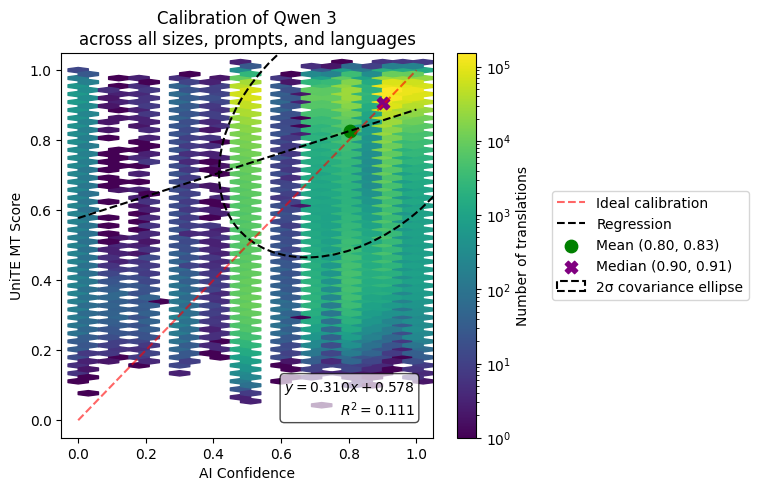

In [49]:
df_all = pd.concat([run.data for run in runs], ignore_index=True)
combined_run = Run(df_all,
                   f"Qwen3 both sizes_all_all_agg.other",
                   {})
plot(combined_run, save=True, save_dir="aggregate", restrict_axis=True, print_fig=True, title="Calibration of Qwen 3\nacross all sizes, prompts, and languages", legend=True)

## Do statistical analysis

In [50]:
print("Total samples")
sum([run.samples for run in runs])

Total samples


4073103

In [51]:
print("Average Errors")
sum([run.info_percents['errors'] for run in runs]) / len(runs)

Average Errors


0.0011299070247933884

In [52]:
print("Average malformatted JSON")
sum([run.info_percents['malformatted_json'] for run in runs]) / len(runs)

Average malformatted JSON


0.0011299070247933884

In [53]:
print("Average NaN confidences")
sum([run.info_percents['nan_confidences'] for run in runs]) / len(runs)

Average NaN confidences


0.0

In [54]:
print("Average other NaNs")
sum([run.info_percents['other_nan'] for run in runs]) / len(runs)

Average other NaNs


0.0

## Expected Calibration Error (ECE)

$$
\text{ECE} = \frac{1}{M} \sum_{b=1}^{M} \lvert \text{acc} (\gamma_b) - \gamma_b \rvert
$$

In [55]:
def predictive_pearson_score(df: pd.DataFrame) -> tuple[float, float]:
    corr, p_value = pearsonr(df['AI_Confidence'], df['Score'])
    return corr, p_value

In [56]:
for model in set([run.model for run in no_berber]):
    for prompt in set([run.prompt for run in no_berber]):
        for thinking in set([run.thinking for run in no_berber]):
            all_langs = [run for run in no_berber if run.model == model and run.thinking == thinking and run.prompt == prompt]
            df_combined = pd.concat([run.data for run in all_langs], ignore_index=True)
            corr, p_value = predictive_pearson_score(df_combined)
            print(f"{model} {prompt} {"thinking" if thinking else "basic"}: corr:{corr:.3f} p:({p_value:.3e}) r2:{corr ** 2:.3f}")

Qwen3-1.7B iterative basic: corr:0.150 p:(0.000e+00) r2:0.022
Qwen3-1.7B iterative thinking: corr:0.070 p:(3.435e-268) r2:0.005
Qwen3-1.7B monolithic basic: corr:0.430 p:(0.000e+00) r2:0.185
Qwen3-1.7B monolithic thinking: corr:0.290 p:(0.000e+00) r2:0.084
Qwen3-14B iterative basic: corr:0.442 p:(0.000e+00) r2:0.195
Qwen3-14B iterative thinking: corr:0.265 p:(0.000e+00) r2:0.070
Qwen3-14B monolithic basic: corr:0.365 p:(0.000e+00) r2:0.133
Qwen3-14B monolithic thinking: corr:0.212 p:(0.000e+00) r2:0.045


In [57]:
corr, p_value = predictive_pearson_score(df_all)
print(f"Overall Pearson: corr:{corr:.3f} p:({p_value:.3e}) r2:{corr ** 2:.3f}")

Overall Pearson: corr:0.333 p:(0.000e+00) r2:0.111


In [58]:
for model in set([run.model for run in no_berber]):
    all_langs = [run for run in no_berber if run.model == model]
    df_combined = pd.concat([run.data for run in all_langs], ignore_index=True)
    corr, p_value = predictive_pearson_score(df_combined)
    print(f"{model}: corr:{corr:.3f} p:({p_value:.3e}) r2:{corr ** 2:.3f}")

Qwen3-1.7B: corr:0.173 p:(0.000e+00) r2:0.030
Qwen3-14B: corr:0.263 p:(0.000e+00) r2:0.069
